# Data Mining: Homework assignment (part 2)

### Theofanis Barmparosos: sdi2200107

### Georgios Spyrou: sdi2200168

Dependencies

In [14]:
!pip install seaborn
!pip install datasets
!pip install matplotlib
!pip install vaderSentiment
!pip install kneed
!pip install contractions
!pip install pyspellchecker

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


For the csv files that this notebook creates, you can edit the number of max_rows below, to load as many rows from the datasets that you desire. We have tested the code on 1000, 10000 and 100000 lines, and the results are of course much better with a higher number of rows.  
We must however warn, that when max_rows exceeds values around 20000, it will require a lot of memory space(RAM) and is very likely to crash the jupyter kernel at the execution of some cell.

In [15]:
# limiting the csv to max_rows to work first
max_rows = 100000000

In [16]:
#########################################
###                                   ###
###           DATA FETCHING           ###
###                                   ###
#########################################
from datasets import load_dataset

print("Reviews:")

beauty_reviews = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_review_All_Beauty", split="full", streaming=True, trust_remote_code=True)
for row in beauty_reviews:
    print(row)
    break #print only the first row for testing.

appliances_reviews = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_review_Appliances", split="full", streaming=True, trust_remote_code=True)
for row in appliances_reviews:
    print(row)
    break #print only the first row for testing.

musical_intruments_reviews = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_review_Musical_Instruments", split="full", streaming=True, trust_remote_code=True)
for row in musical_intruments_reviews:
    print(row)
    break #print only the first row for testing.

software_reviews = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_review_Software", split="full", streaming=True, trust_remote_code=True)
for row in software_reviews:
    print(row)
    break #print only the first row for testing.

video_games_reviews = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_review_Video_Games", split="full", streaming=True, trust_remote_code=True)
for row in video_games_reviews:
    print(row)
    break #print only the first row for testing.


print("Meta data:")

beauty_meta = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_meta_All_Beauty", split="full", streaming=True, trust_remote_code=True)
for row in beauty_meta:
    print(row)
    break #print only the first row for testing.

appliances_meta = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_meta_Appliances", split="full", streaming=True, trust_remote_code=True)
for row in appliances_meta:
    print(row)
    break #print only the first row for testing.

musical_instruments_meta = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_meta_Musical_Instruments", split="full", streaming=True, trust_remote_code=True)
for row in musical_instruments_meta:
    print(row)
    break #print only the first row for testing.

software_meta = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_meta_Software", split="full", streaming=True, trust_remote_code=True)
for row in software_meta:
    print(row)
    break #print only the first row for testing.

video_games_meta = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_meta_Video_Games", split="full", streaming=True, trust_remote_code=True)
for row in video_games_meta:
    print(row)
    break #print only the first row for testing.

Reviews:
{'rating': 5.0, 'title': 'Such a lovely scent but not overpowering.', 'text': "This spray is really nice. It smells really good, goes on really fine, and does the trick. I will say it feels like you need a lot of it though to get the texture I want. I have a lot of hair, medium thickness. I am comparing to other brands with yucky chemicals so I'm gonna stick with this. Try it!", 'images': [], 'asin': 'B00YQ6X8EO', 'parent_asin': 'B00YQ6X8EO', 'user_id': 'AGKHLEW2SOWHNMFQIJGBECAF7INQ', 'timestamp': 1588687728923, 'helpful_vote': 0, 'verified_purchase': True}
{'rating': 5.0, 'title': 'Work great', 'text': 'work great. use a new one every month', 'images': [], 'asin': 'B01N0TQ0OH', 'parent_asin': 'B01N0TQ0OH', 'user_id': 'AGKHLEW2SOWHNMFQIJGBECAF7INQ', 'timestamp': 1519317108692, 'helpful_vote': 0, 'verified_purchase': True}
{'rating': 5.0, 'title': 'Five Stars', 'text': 'Great headphones, comfortable and sound is good. No complaints. I would buy again.', 'images': [], 'asin': 'B

Creating the CSV files from streaming, with, only the necessary lines until max_rows.  

`!Important!`
For this part we chose to work only with the category video_games, entirely because of the limited resources. More than one category for more than ~20000 lines, would risk the kernel crashing before it finishes executing the notebook when ran on our devices.

In [17]:
# CSV creation

# our categories in a list for easy access
categories = ["appliances", "beauty", "musical_instruments", "software", "video_games"]

import csv
import os
import pandas as pd


# reviews
columns = []
for row in beauty_reviews:
    for item in row:
        # print(item, " : ", row[item])
        # the columns of the csvs are all the same, so we will make it once and add it to each csv file
        columns.append(item)
    break

for category in categories:
    with open(f"./{category}_reviews.csv", "w+", newline="", encoding="utf-8") as file:
        # appending the header (column names) to the csv file
        writer = csv.writer(file, escapechar='\\')
        writer.writerow(columns)
        count = 0
        for row in beauty_reviews:
            if count > max_rows:
                break
            count += 1
            csv_row = []
            for item in row:
                csv_row.append(row[item])
            writer.writerow(csv_row)
    print(f"Finished writing csv with {category}_reviews")


# meta data
columns = []
for row in beauty_meta:
    for item in row:
        # print(item, " : ", row[item])
        # the columns of the csvs are all the same, so we will make it once and add it to each csv file
        columns.append(item)
    break

for category in categories:
    with open(f"./{category}_meta.csv", "w+", newline="", encoding="utf-8") as file:
        # appending the header (column names) to the csv file
        writer = csv.writer(file, escapechar='\\')
        writer.writerow(columns)
        count = 0
        for row in beauty_meta:
            if count > max_rows:
                break
            count += 1
            csv_row = []
            for item in row:
                csv_row.append(row[item])
            writer.writerow(csv_row)
    print(f"Finished writing csv with {category}_meta")



# The two lines below produce the same result. They aren't optimal because,
# they fetch the whole dataset first and then only keep the max_rows whereas
# with the method above, we are able to fetch and create the csv files with
# the necessary lines only("max_rows"). And this is why it isn't used.

# pd.DataFrame(beauty_reviews).head(max_rows).to_csv("beauty_reviews.csv", index=False)
# pd.DataFrame(beauty_meta).head(max_rows).to_csv("beauty_meta.csv", index=False)

Finished writing csv with appliances_reviews
Finished writing csv with beauty_reviews
Finished writing csv with musical_instruments_reviews
Finished writing csv with software_reviews
Finished writing csv with video_games_reviews
Finished writing csv with appliances_meta
Finished writing csv with beauty_meta
Finished writing csv with musical_instruments_meta
Finished writing csv with software_meta
Finished writing csv with video_games_meta


Dataframes from CSVs

In [18]:
# DEBUG
# categories = ["video_games"]

# two dictionaries, one for reviews dataframes, one for meta dataframes
reviews_dfs = {}
meta_dfs = {}
for category in categories:
    reviews_csv_file = f"./{category}_reviews.csv"
    meta_csv_file = f"./{category}_meta.csv"
    reviews_dfs[category] = pd.read_csv(reviews_csv_file)
    meta_dfs[category] = pd.read_csv(meta_csv_file)
    print(f"Created dataframes for {category}")


Created dataframes for appliances
Created dataframes for beauty
Created dataframes for musical_instruments
Created dataframes for software
Created dataframes for video_games


We're starting off with some basic preprocessing and normalization of the dataset. When doing wordclouds we noticed that a lot of HTML elements would show up, so we are removing HTML elements from the review texts. Another issue were the missing values for the price column, in the metadata datasets. We can't have "None" values for fileds as important as prices, so we decided to replace "None" price values, with the mean price of the whole dataset.

In [19]:
###########################################
###                                     ###
###       HANDLING MISSING VALUES       ###
###                                     ###
###########################################

def display_number_of_null(df):
    columns = [
        'price', 'average_rating', 'rating_number', 'features',
        'description', 'images', 'videos', 'store', 'categories',
        'details', 'parent_asin', 'bought_together', 'subtitle', 'author'
    ]

    for col in columns:
        col_sum = df[col].isnull().sum()    
        print(f"Column \"{col}\" has {col_sum} null values")
    print("\n")

for category, df in meta_dfs.items():
    text = f" {category} "
    pad = 40 - len(text)
    left = pad // 2
    right = pad - left
    print("=" * left + text + "=" * right)
    display_number_of_null(df)


def get_mean_price_from_df(df):
    # converts column price to numbers, and non-numerics to NaN
    df['price'] = pd.to_numeric(df['price'], errors='coerce')
    return df['price'].mean()

appliances_mean = get_mean_price_from_df(meta_dfs['appliances'])
print('The average product price in category "appliances" is', appliances_mean)

beauty_mean = get_mean_price_from_df(meta_dfs['beauty'])
print('The average product price in category "beauty" is', beauty_mean)

musical_instruments_mean = get_mean_price_from_df(meta_dfs['musical_instruments'])
print('The average product price in category "musical instruments" is', musical_instruments_mean)

software_mean = get_mean_price_from_df(meta_dfs['software'])
print('The average product price in category "software" is', software_mean)

video_games_mean = get_mean_price_from_df(meta_dfs['video_games'])
print('The average product price in category "video games" is', video_games_mean)

============== appliances ==============
Column "price" has 94886 null values
Column "average_rating" has 0 null values
Column "rating_number" has 0 null values
Column "features" has 0 null values
Column "description" has 0 null values
Column "images" has 0 null values
Column "videos" has 0 null values
Column "store" has 11344 null values
Column "categories" has 0 null values
Column "details" has 0 null values
Column "parent_asin" has 0 null values
Column "bought_together" has 112590 null values
Column "subtitle" has 112590 null values
Column "author" has 112590 null values


================ beauty ================
Column "price" has 94886 null values
Column "average_rating" has 0 null values
Column "rating_number" has 0 null values
Column "features" has 0 null values
Column "description" has 0 null values
Column "images" has 0 null values
Column "videos" has 0 null values
Column "store" has 11344 null values
Column "categories" has 0 null values
Column "details" has 0 null values
Col

In [20]:
def replace_invalid_prices(df, mean):
    df['price'] = pd.to_numeric(df['price'], errors='coerce') # coerce replaces any non-numeric value with NaN
    # locates the rows that have bad 'price' value and replaces the 'price' in these rows with the mean value provided
    df.loc[(df['price'].isna()) | (df['price'] <= 0.0), 'price'] = mean
    return df

# # replacing all bad values with the mean value of the rest
replace_invalid_prices(meta_dfs['appliances'], appliances_mean)
replace_invalid_prices(meta_dfs['beauty'], beauty_mean)
replace_invalid_prices(meta_dfs['musical_instruments'], musical_instruments_mean)
replace_invalid_prices(meta_dfs['software'], software_mean)
replace_invalid_prices(meta_dfs['video_games'], video_games_mean)

# these should be now zero
for category in categories:
    df_nulls = (meta_dfs[category])['price'].isnull().sum()
    print(f"{df_nulls}")

0
0
0
0
0


#### Task 1: Clustering for Product Grouping

In [22]:
#######################################################
###                                                 ###
###          META DATA TEXT PRE-PROCESSING          ###
###                                                 ###
#######################################################

import re
import html
import contractions
from spellchecker import SpellChecker

emoji_dict = {
    r":\)": "smile",
    r":D": "smile",
    r";\)": "wink",
    r":\(": "sad",
    r":'\(": "cry",
    r":P": "playful",
    r"XD": "laugh",
    r"xD": "laugh",
    r"<3": "love",
    r":O": "surprise"
}

def handle_simple_emojis(text):
    for pattern, replacement in emoji_dict.items():
        text = re.sub(pattern, replacement, text)
    return text

def remove_contractions(text):
    # expand contractions (e.g haven't -> have not)
    return contractions.fix(text)

# initialize spell checker
spell = SpellChecker(distance=1)

def my_spellcheck(text):
    words = text.split()
    corrected_words = []
    for word in words:
        # if it's wrong
        if word not in spell:
            test_word = spell.correction(word)
            # found correction
            if test_word is not None:
                corrected_words.append(test_word)
            # didn't find correction
            else:
                corrected_words.append(word)
        # else, if it's correct, append it to the corrected
        else:
            corrected_words.append(word)
    return " ".join(corrected_words)

def text_cleanup(text):
    text = text.lower() # lowercase everything
    text = handle_simple_emojis(text) # handling basic emojis
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', 'email', text) # handle email adresses
    text = re.sub(r'http[s]?://\S+', 'url', text) # handle urls
    text = re.sub(r'@\w+', 'username', text) # handle mentions
    text = re.sub(r'#(\w+)', r'\1', text) # handle hashtags: remove the symbol, keep the text
    text = html.unescape(text) # handling html tags
    text = re.sub(r'(\w)\1{2,}', r'\1\1', text) # handling unecessarily long words (e.g. soooooo -> so)
    text = remove_contractions(text) # handling contractions (haven't -> have not)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text) # remove anything that is not english, a number or a whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # we didn't use pyspellchecker because it would remove significant points from
    # the text that could be vital for text manipulation later, also it would take
    # too much time
    # text = my_spellcheck(text) # spellchecking using pyspellchecker
    return text

# apply cleanup to all datasets
print("Cleaning data...")
for category in categories:
    print(f"{'=' * 18} {category.center(21)} {'=' * 18}")
    re_df = meta_dfs[category]
    re_df['description'] = re_df['description'].fillna("").astype(str)
    re_df['description'] = re_df['description'].apply(text_cleanup)
    print(re_df['description'].head())
    print("")

Cleaning data...
==================       appliances      ==================
0                                                     
1                                                     
2                                                     
3                                                     
4    the precision plunger bars are designed to wor...
Name: description, dtype: object

==================         beauty        ==================
0                                                     
1                                                     
2                                                     
3                                                     
4    the precision plunger bars are designed to wor...
Name: description, dtype: object

==================  musical_instruments  ==================
0                                                     
1                                                     
2                                                     
3                   

In [23]:
#############################################################
###                                                       ###
###           TF-IDF ENCODING OF META DATA TEXT           ###
###                                                       ###
#############################################################

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix

# initialize TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,  # limit vocabulary size for efficiency
    stop_words='english',  # remove English stopwords
    ngram_range=(1, 3)  # consider both single words and bi-grams
)

# dictionary to store TF-IDF matrices for each category
tfidf_matrices = {}

for category in categories:
    print(f"Processing TF-IDF for {category}...")
    
    # cleaned text data (description)
    texts = meta_dfs[category]['description']
    # fit and transform
    tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
    tfidf_matrices[category] = tfidf_matrix
    
    print(f"Shape of TF-IDF matrix for {category}: {tfidf_matrix.shape}")


print("")
# joining TF-IDF values and numerical data into one matrix and standardization
feature_matrices = {}
for category in categories:
    numerical_data = meta_dfs[category][['price', 'average_rating']].fillna(0)
    # standardizing numerical data
    scaler = StandardScaler()
    numerical_scaled = scaler.fit_transform(numerical_data)
    # joining TF-IDF and numerical data into one feature matrix
    feature_matrices[category] = hstack([tfidf_matrices[category], csr_matrix(numerical_scaled)])
    print(f"TF-IDF shape for {category}: {tfidf_matrices[category].shape}, "
      f"Numerical shape: {numerical_scaled.shape}, "
      f"Combined shape: {feature_matrices[category].shape}")

Processing TF-IDF for appliances...
Shape of TF-IDF matrix for appliances: (112590, 5000)
Processing TF-IDF for beauty...
Shape of TF-IDF matrix for beauty: (112590, 5000)
Processing TF-IDF for musical_instruments...
Shape of TF-IDF matrix for musical_instruments: (112590, 5000)
Processing TF-IDF for software...
Shape of TF-IDF matrix for software: (112590, 5000)
Processing TF-IDF for video_games...
Shape of TF-IDF matrix for video_games: (112590, 5000)

TF-IDF shape for appliances: (112590, 5000), Numerical shape: (112590, 2), Combined shape: (112590, 5002)
TF-IDF shape for beauty: (112590, 5000), Numerical shape: (112590, 2), Combined shape: (112590, 5002)
TF-IDF shape for musical_instruments: (112590, 5000), Numerical shape: (112590, 2), Combined shape: (112590, 5002)
TF-IDF shape for software: (112590, 5000), Numerical shape: (112590, 2), Combined shape: (112590, 5002)
TF-IDF shape for video_games: (112590, 5000), Numerical shape: (112590, 2), Combined shape: (112590, 5002)


/home/fanisbar/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "



Running Elbow Method for category: appliances
Optimal number of clusters for appliances: 6


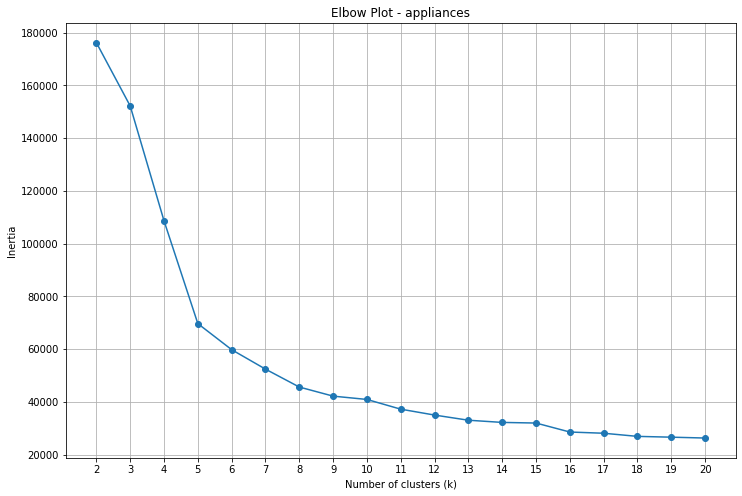


Running Elbow Method for category: beauty
Optimal number of clusters for beauty: 6


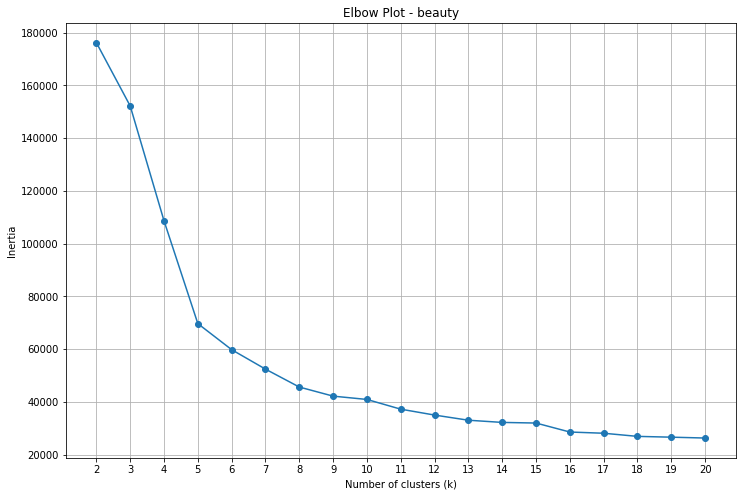


Running Elbow Method for category: musical_instruments
Optimal number of clusters for musical_instruments: 6


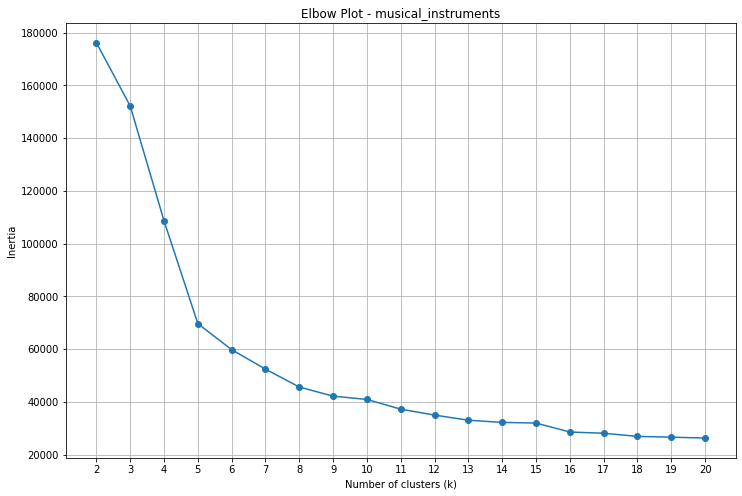


Running Elbow Method for category: software
Optimal number of clusters for software: 6


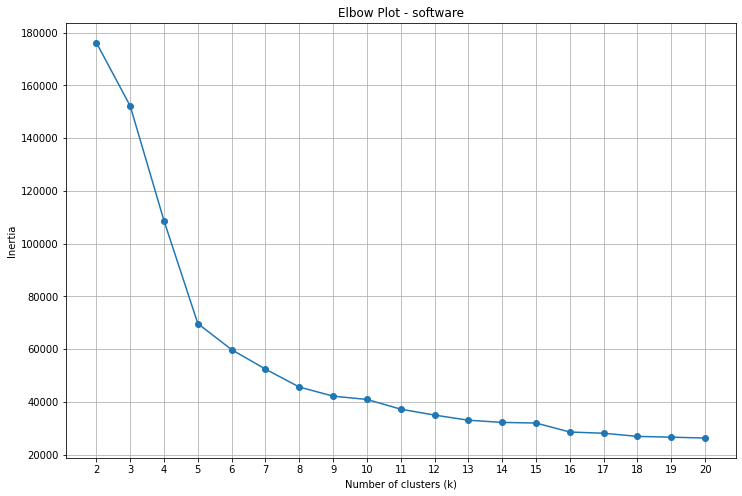


Running Elbow Method for category: video_games
Optimal number of clusters for video_games: 6


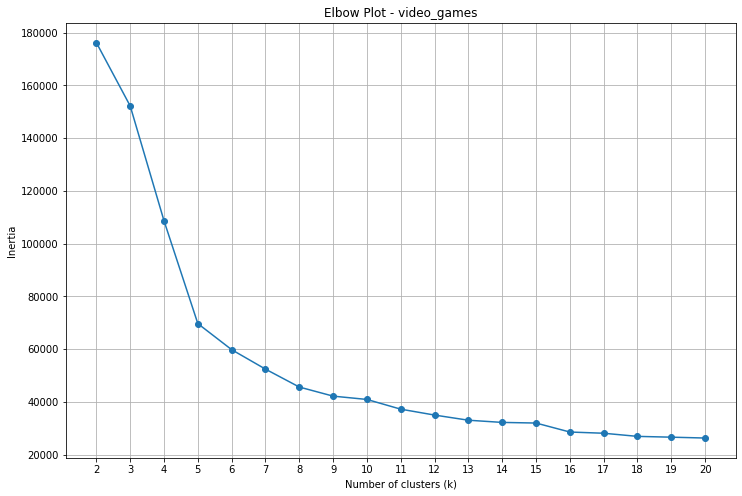




Performing KMeans clustering for "appliances"...
Silhouette Score for appliances: 0.3669


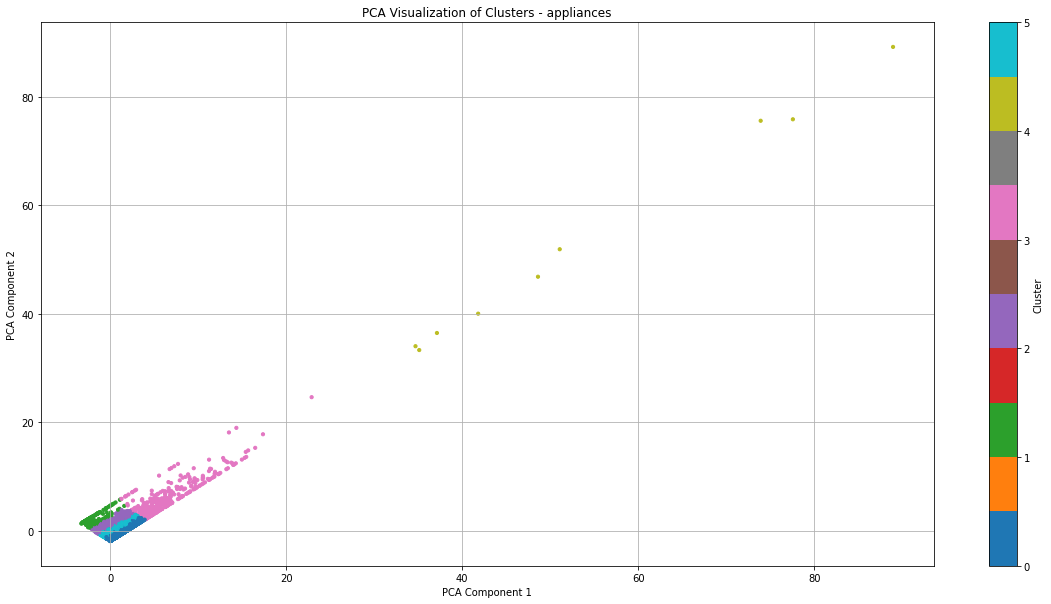


Performing KMeans clustering for "beauty"...
Silhouette Score for beauty: 0.3669


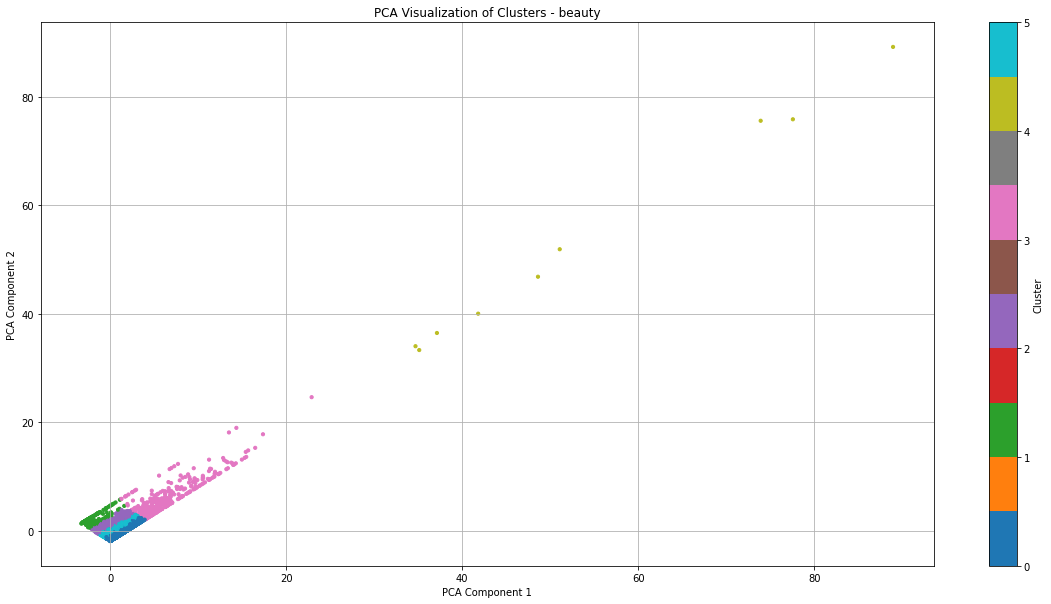


Performing KMeans clustering for "musical_instruments"...
Silhouette Score for musical_instruments: 0.3669


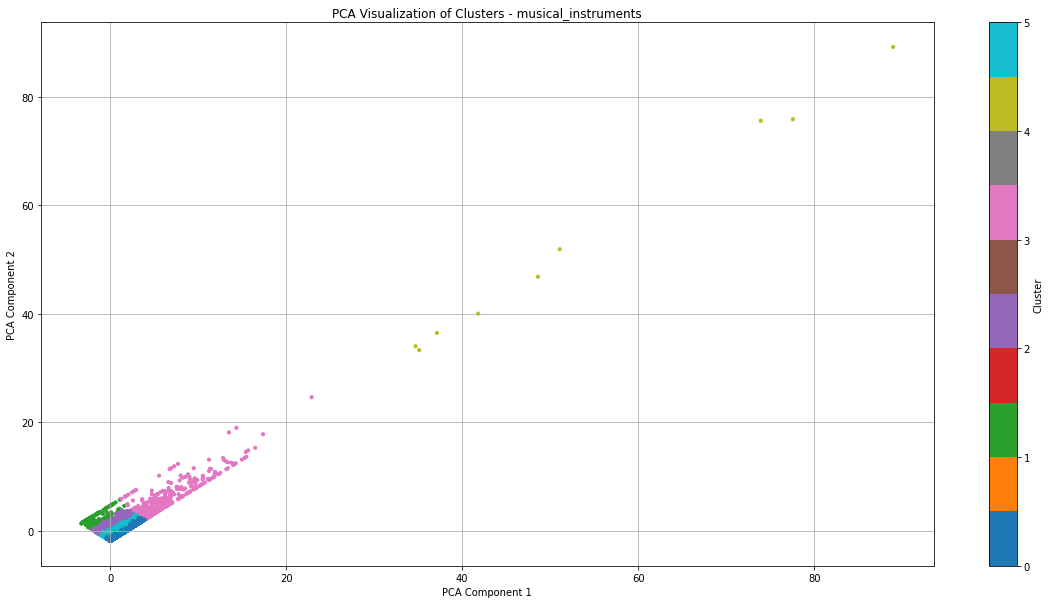


Performing KMeans clustering for "software"...
Silhouette Score for software: 0.3669


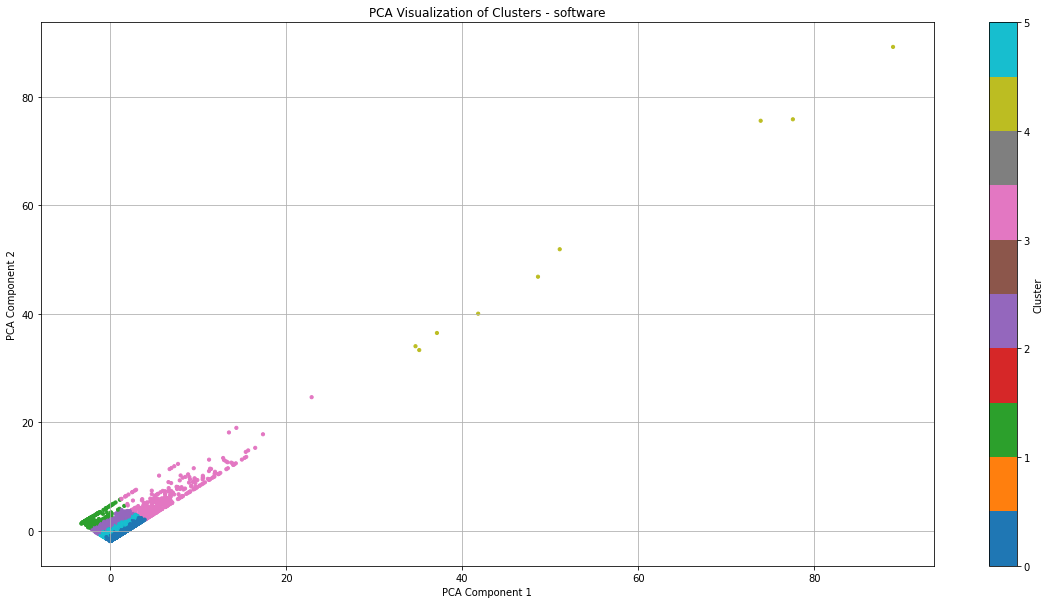


Performing KMeans clustering for "video_games"...
Silhouette Score for video_games: 0.3669


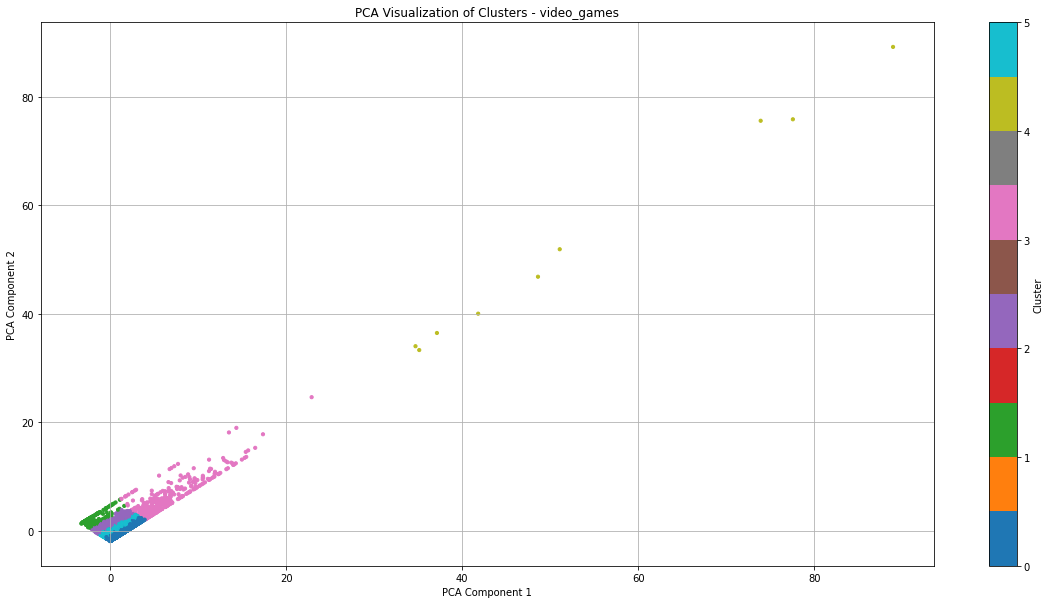

In [10]:
##############################################
###                                        ###
###               CLUSTERING               ###
###                                        ###
##############################################

from sklearn.cluster import KMeans
from kneed import KneeLocator
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Finding the optimal number of clusters for each category first

# we will use the elbow method to determine which number of
# clusters provides the optimal insertia value
# (sum of squares of distances from the center of the cluster)
K_range = list(range(2, 21))
optimal_k = {}
for category in categories:
    print(f"\nRunning Elbow Method for category: {category}")
    X = feature_matrices[category]
    inertia = []

    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(X)
        inertia.append(kmeans.inertia_)

    kneedle = KneeLocator(K_range, inertia, curve='convex', direction='decreasing')
    optimal_k[category] = kneedle.elbow
    print(f"Optimal number of clusters for {category}: {optimal_k[category]}")

    # plot for each category
    plt.figure(figsize=(12, 8))
    plt.xticks(K_range)
    plt.plot(K_range, inertia, marker='o')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Inertia')
    plt.title(f'Elbow Plot - {category}')
    plt.grid(True)
    plt.show()

print("\n")


silhouette_scores = {}

for category in categories:
    print(f"\nPerforming KMeans clustering for \"{category}\"...")
    X = feature_matrices[category]
    k = optimal_k[category]

    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X)

    score = silhouette_score(X, cluster_labels)
    silhouette_scores[category] = score
    print(f"Silhouette Score for {category}: {score:.4f}")

    # plot 2D PCA visualization of clusters
    pca = PCA(n_components=2)
    X_dense = X.toarray() if hasattr(X, "toarray") else X
    X_reduced = pca.fit_transform(X_dense)

    plt.figure(figsize=(20, 10))
    scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=cluster_labels, cmap='tab10', s=10)
    plt.title(f"PCA Visualization of Clusters - {category}")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.colorbar(scatter, label='Cluster')
    plt.grid(True)
    plt.show()

#### Task 2: Recommendation System

In [24]:
##############################################################
###                                                        ###
###           ITEM-BASED COLLABORATIVE FILTERING           ###
###                                                        ###
##############################################################

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

# create sparse user-item matrix
user_item_matrices = {}
user_index_maps = {}
item_index_maps = {}

for category in categories:
    
    df = reviews_dfs[category][['user_id', 'parent_asin', 'rating']].dropna()

    # map users & items -> integers (indices)
    df['user_idx'] = df['user_id'].astype('category').cat.codes
    df['item_idx'] = df['parent_asin'].astype('category').cat.codes

    user_index_maps[category] = dict(enumerate(df['user_id'].astype('category').cat.categories))
    item_index_maps[category] = dict(enumerate(df['parent_asin'].astype('category').cat.categories))

    matrix = csr_matrix(
        (df['rating'], (df['user_idx'], df['item_idx']))
    )

    user_item_matrices[category] = matrix

    print(f"{category} user-item shape: {matrix.shape}")

# sparse item-item similarity
item_similarity_matrices = {}

for category in categories:
    X = user_item_matrices[category].T              # items × users
    sim = cosine_similarity(X, dense_output=False)  # sparse cosine similarity
    item_similarity_matrices[category] = sim
    print(f"{category} item-similarity shape: {sim.shape}")


appliances user-item shape: (631986, 112565)
beauty user-item shape: (631986, 112565)
musical_instruments user-item shape: (631986, 112565)
software user-item shape: (631986, 112565)
video_games user-item shape: (631986, 112565)
appliances item-similarity shape: (112565, 112565)
beauty item-similarity shape: (112565, 112565)
musical_instruments item-similarity shape: (112565, 112565)
software item-similarity shape: (112565, 112565)
video_games item-similarity shape: (112565, 112565)


In [25]:
# recommending products to user
def recommend_items_item_based(user_id, category, top_n=5):

    # decode index from original ids
    user_map = {v:k for k,v in user_index_maps[category].items()}
    item_map = item_index_maps[category]

    if user_id not in user_map:
        print(f"User {user_id} not found in '{category}'")
        return

    u = user_map[user_id]

    # ratings of current user
    user_vector = user_item_matrices[category][u].toarray().ravel()

    rated = np.where(user_vector > 0)[0]
    if len(rated) == 0:
        print(f"User {user_id} has no ratings in '{category}'")
        return

    sim = item_similarity_matrices[category]

    # compute recommendation score
    scores = np.zeros(sim.shape[0])

    for i in rated:
        scores += sim[i].toarray().ravel() * user_vector[i]

    # excluding already rated products
    scores[rated] = -np.inf

    best = np.argsort(scores)[::-1][:top_n]

    meta = meta_dfs[category]

    print(f"\nRecommendations for user {user_id} in '{category}':\n")

    for i, item_idx in enumerate(best, start=1):
        asin = item_map[item_idx]
        title = meta.loc[meta['parent_asin'] == asin, 'title'].values
        title = title[0] if len(title) else "No title"
        print(f"{i}. {title}  (ASIN: {asin})")


# test
some_user_id = list(reviews_dfs["video_games"]['user_id'].dropna().unique())[0]
recommend_items_item_based(some_user_id, "video_games", 5)

# old test
# some_user_id = user_item_matrices["video_games"].index[0]
# recommend_items_item_based(some_user_id, "video_games", 3)

# testing for recommendations in different categories
# for category in categories:
#     recommend_items(some_user_id, category, top_n=3)


Recommendations for user AGKHLEW2SOWHNMFQIJGBECAF7INQ in 'video_games':

1. Tweezerman Folding Eyelash Comb (Pack of 2)  (ASIN: B06XSN9J9L)
2. Eco-Friendly Lava Pumice Stone for feet - Callus Remover for feet and hands - Natural Foot Scrubber for Exfoliation to Remove Dead Skin – Pedicure Foot Care Gift Set with Organic Loofah Pad & Tray  (ASIN: B083W353T4)
3. Ships From CA, USA. Nail Drill Bits Sanding Bands for Manicure Pedicure Nail Tools Machine 50pcs/size, 3 Sizes #80, 120, 180  (ASIN: B00XJ0D1XG)
4. North American Herb and Spice North american herb and spice: sinuorega natural aromatic p73 spice formula, 2 fl oz  (ASIN: B00NP4RLA0)
5. 1.5" Heart Shape Kraft Paper Thank You Adhesive Label, 500 Stickers per Roll, Love Shape, 1-1/2 Inch  (ASIN: B01N47XMWS)


In [26]:
##############################################################
###                                                        ###
###           USER-BASED COLLABORATIVE FILTERING           ###
###                                                        ###
##############################################################

from sklearn.metrics.pairwise import cosine_similarity

user_similarity_matrices = {}

for category in categories:
    X = user_item_matrices[category]          # users × items (csr)
    sim = cosine_similarity(X, dense_output=False)  # users × users (SPARSE)
    user_similarity_matrices[category] = sim

    print(f"{category} user-similarity shape: {sim.shape}")

def get_top_k_neighbors_sparse(user_id, category, k=5):

    user_map = {v: k for k, v in user_index_maps[category].items()}
    sim = user_similarity_matrices[category]

    if user_id not in user_map:
        print(f"User {user_id} not found in '{category}'")
        return []

    u = user_map[user_id]

    # sparse row → dense vector μόνο για 1 χρήστη
    similarities = sim[u].toarray().ravel()
    similarities[u] = -np.inf  # exclude self

    top_k_idx = np.argsort(similarities)[::-1][:k]

    return top_k_idx
























# def get_top_k_neighbors(user_id, category, k=5):
#     user_sim_matrix = user_similarity_matrices[category]
    
#     # if the user exists
#     if user_id not in user_sim_matrix.index:
#         print(f"\nUser {user_id} not found in category '{category}'.")
#         return []
    
#     similarity_scores = user_sim_matrix.loc[user_id]
#     # we don't need the specific user
#     similarity_scores = similarity_scores.drop(user_id)
#     # sorting based on descending similarity (top k of them)
#     top_k_users = similarity_scores.sort_values(ascending=False).head(k).index.tolist()
    
#     return top_k_users

# user_similarity_matrices = {}

# for category in categories:
#     matrix = user_item_matrices[category]  # rows: users, columns: products
#     similarity = cosine_similarity(matrix)  # similarity between users
#     user_ids = matrix.index
#     user_similarity_matrices[category] = pd.DataFrame(similarity, index=user_ids, columns=user_ids)
    
#     print(f"User-User Similarity Matrix for '{category}':")
#     print(user_similarity_matrices[category].shape)


# some_user_id = user_item_matrices["video_games"].index[0]
# neighbors = get_top_k_neighbors(some_user_id, "video_games", 3)
# if neighbors:
#     print(f"\nFor {some_user_id} the top similar users are:")
#     print(neighbors)
# else:
#     print(f"No recommendations could be made for user {some_user_id}.\n")

appliances user-similarity shape: (631986, 631986)
beauty user-similarity shape: (631986, 631986)
musical_instruments user-similarity shape: (631986, 631986)
software user-similarity shape: (631986, 631986)
video_games user-similarity shape: (631986, 631986)


In [29]:
# recommending products to user

def recommend_items_user_based_sparse(user_id, category, top_n=5, k=5):

    user_map = {v: k for k, v in user_index_maps[category].items()}
    item_map = item_index_maps[category]

    if user_id not in user_map:
        print(f"User {user_id} not found in '{category}'")
        return

    u = user_map[user_id]

    matrix = user_item_matrices[category]      # csr
    sim = user_similarity_matrices[category]   # csr

    neighbors = get_top_k_neighbors_sparse(user_id, category, k)
    if len(neighbors) == 0:
        print(f"No similar users found.")
        return

    user_vector = matrix[u].toarray().ravel()
    rated = np.where(user_vector > 0)[0]

    scores = np.zeros(matrix.shape[1])
    sim_sums = np.zeros(matrix.shape[1])

    for v in neighbors:
        similarity = sim[u, v]
        if similarity <= 0:
            continue

        neighbor_ratings = matrix[v].toarray().ravel()

        scores += similarity * neighbor_ratings
        sim_sums += similarity * (neighbor_ratings > 0)

    # avoid division by zero
    mask = sim_sums > 0
    scores[mask] /= sim_sums[mask]
    scores[~mask] = 0

    # exclude already rated items
    scores[rated] = -np.inf

    best = np.argsort(scores)[::-1][:top_n]

    meta = meta_dfs[category]

    print(f"\nUser-Based Recommendations for user {user_id} in '{category}':\n")

    for i, item_idx in enumerate(best, start=1):
        asin = item_map[item_idx]
        title = meta.loc[meta['parent_asin'] == asin, 'title'].values
        title = title[0] if len(title) else "No title"
        print(f"{i}. {title} (ASIN: {asin})")

some_user_id = list(reviews_dfs["video_games"]['user_id'].dropna().unique())[0]

for category in categories:
    recommend_items_user_based_sparse(
        some_user_id,
        category,
        top_n=3,
        k=5
    )
















# def recommend_items_user_based(user_id, category, top_n=5, k=5):
#     if user_id not in user_item_matrices[category].index:
#         print(f"User {user_id} hasn't interacted with the category '{category}'.\n")
#         return []

#     user_matrix = user_item_matrices[category]
#     user_sim_matrix = user_similarity_matrices[category]
#     neighbors = get_top_k_neighbors(user_id, category, k)
#     if not neighbors:
#         print(f"No similar users found for user {user_id} in category '{category}'.\n")
#         return []

#     # user's ratings
#     user_ratings = user_matrix.loc[user_id]
#     rated_items = user_ratings[user_ratings > 0].index

#     if rated_items.empty:
#         print(f"User {user_id} has not rated any items in category '{category}'.\n")
#         return []

#     # predicting rating for every product he hasn't seen
#     scores = {}
#     for neighbor in neighbors:
#         similarity = user_sim_matrix.loc[user_id, neighbor]
#         neighbor_ratings = user_matrix.loc[neighbor]

#         for item, rating in neighbor_ratings.items():
#             if item in rated_items or rating == 0:
#                 continue
#             if item not in scores:
#                 scores[item] = [0.0, 0.0]
#             # [sum(sim * rating), sum(sim)]
#             scores[item][0] += similarity * rating
#             scores[item][1] += similarity

#     # final predicted rating for each item
#     predicted_scores = {
#         item: (score_sum / sim_sum)
#         for item, (score_sum, sim_sum) in scores.items()
#         if sim_sum > 0
#     }

#     if not predicted_scores:
#         print(f"No recommendations could be made for user {user_id} in category '{category}'.\n")
#         return []

#     # keep the top_n items
#     top_items = sorted(predicted_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]

#     # also getting the titles from asins
#     meta_df = meta_dfs[category]
#     print(f"User-Based Recommendations for user {user_id} in category '{category}':")
#     print(f"aka: From {category}, you might also like:\n")
#     for i, (asin, score) in enumerate(top_items, start=1):
#         title = meta_df.loc[meta_df['parent_asin'] == asin, 'title'].values
#         title_str = title[0] if len(title) > 0 else "No title found"
#         print(f"{i}. {title_str} (ASIN: {asin}) - Predicted rating: {score:.2f}")
#     print("")

#     return [asin for asin, _ in top_items]


# some_user_id = user_item_matrices["video_games"].index[0]
# for category in categories:
#     recommend_items_user_based(some_user_id, category, 3)



User-Based Recommendations for user AGKHLEW2SOWHNMFQIJGBECAF7INQ in 'appliances':

1. Lattafa Perfumes Thouq for Unisex Eau de Parfum Spray, 2.7 Ounce (ASIN: B0CHXWTSM6)
2. Hairitory Ombre Malaysian Body Wave Bundles with Lace Closure, 8A Virgin Hair 3 Bundles Blonde Human Hair bundles with Closure 100g/PC (16 with 20 20 20, T1B/4/30) (ASIN: B0718XMBW1)
3. Live Clean Coconut Milk Moisturizing Body Wash (Pack of 2) with Certified Organic Coconut Extract and Oil, Petrolatum-free, Phthalate-free and Paraben-free, 17 oz (ASIN: B071796K4M)

User-Based Recommendations for user AGKHLEW2SOWHNMFQIJGBECAF7INQ in 'beauty':

1. Lattafa Perfumes Thouq for Unisex Eau de Parfum Spray, 2.7 Ounce (ASIN: B0CHXWTSM6)
2. Hairitory Ombre Malaysian Body Wave Bundles with Lace Closure, 8A Virgin Hair 3 Bundles Blonde Human Hair bundles with Closure 100g/PC (16 with 20 20 20, T1B/4/30) (ASIN: B0718XMBW1)
3. Live Clean Coconut Milk Moisturizing Body Wash (Pack of 2) with Certified Organic Coconut Extract and 

In [30]:
#####################################################
###                                               ###
###            CONTENT-BASED FILTERING            ###
###                                               ###
#####################################################

from gensim.models import KeyedVectors
from tqdm import tqdm

path = "./GoogleNews-vectors-negative300/GoogleNews-vectors-negative300.bin"

print("Loading Word2Vec model...")
word2vec_model = KeyedVectors.load_word2vec_format(path, binary=True)
print("Model loaded successfully.")


def get_mean_vector(text, model):
    words = re.findall(r'\b\w+\b', str(text).lower())
    vectors = [model[word] for word in words if word in model]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)  # fallback: zero vector

# dictionary to store content vectors (one per product description)
content_vectors = {}

for category in categories:
    print(f"Vectorizing descriptions for category: {category}...")
    descriptions = meta_dfs[category]['description']
    vectors = []
    
    for desc in tqdm(descriptions, desc=f"{category}"):
        vec = get_mean_vector(desc, word2vec_model)
        vectors.append(vec)
    
    content_vectors[category] = np.vstack(vectors)
    print(f"Vector shape for {category}: {content_vectors[category].shape}")


# creating content based similarity matrices
content_similarity_matrices = {}

for category in categories:
    print(f"Computing content similarity for: {category}")
    
    vectors = content_vectors[category]  # [num_of_products, 300]
    similarity = cosine_similarity(vectors)  # [num_of_products, num_of_products]
    
    asins = meta_dfs[category]['parent_asin'].values
    sim_df = pd.DataFrame(similarity, index=asins, columns=asins)
    
    content_similarity_matrices[category] = sim_df
    print(f"Similarity matrix shape for {category}: {sim_df.shape}")

Loading Word2Vec model...


: 

In [ ]:
# recommending products to user

def recommend_items_content_based(user_id, category, top_n=5):
    if user_id not in user_item_matrices[category].index:
        print(f"User {user_id} not found in category '{category}'.\n")
        return []
    
    user_ratings = user_item_matrices[category].loc[user_id]
    rated_items = user_ratings[user_ratings > 0].index.tolist()
    
    if not rated_items:
        print(f"User {user_id} has not rated any items in category '{category}'.\n")
        return []

    similarity_matrix = content_similarity_matrices[category]
    
    scores = {}
    for item in rated_items:
        if item not in similarity_matrix.index:
            continue
        similar_items = similarity_matrix[item]
        for other_item, score in similar_items.items():
            if other_item in rated_items or other_item == item:
                continue
            if other_item not in scores:
                scores[other_item] = 0.0
            scores[other_item] += score

    if not scores:
        print(f"No content-based recommendations found for user {user_id} in '{category}'.\n")
        return []

    # sort by score
    recommended_items = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    
    meta_df = meta_dfs[category]
    print(f"\nContent-Based Recommendations for user {user_id} in '{category}':\n")
    for i, (asin, score) in enumerate(recommended_items, start=1):
        title = meta_df.loc[meta_df['parent_asin'] == asin, 'title'].values
        title_str = title[0] if len(title) > 0 else "No title found"
        print(f"{i}. {title_str} (ASIN: {asin}) - Similarity score: {score:.3f}")
    
    return [asin for asin, _ in recommended_items]



some_user_id = user_item_matrices["video_games"].index[1]
recommend_items_content_based(some_user_id, "video_games", 5)

In [ ]:
#################################################
###                                           ###
###              HYBRID APPROACH              ###
###                                           ###
#################################################


# we need to get the cf scores for the average calculation
def get_cf_scores(user_id, category, k=5):
    if user_id not in user_item_matrices[category].index:
        return {}

    user_matrix = user_item_matrices[category]
    user_sim_matrix = user_similarity_matrices[category]
    neighbors = get_top_k_neighbors(user_id, category, k)
    if not neighbors:
        return {}

    user_ratings = user_matrix.loc[user_id]
    rated_items = user_ratings[user_ratings > 0].index

    scores = {}
    for neighbor in neighbors:
        similarity = user_sim_matrix.loc[user_id, neighbor]
        neighbor_ratings = user_matrix.loc[neighbor]

        for item, rating in neighbor_ratings.items():
            if item in rated_items or rating == 0:
                continue
            if item not in scores:
                scores[item] = [0.0, 0.0]
            scores[item][0] += similarity * rating
            scores[item][1] += similarity

    predicted_scores = {
        item: (score_sum / sim_sum)
        for item, (score_sum, sim_sum) in scores.items()
        if sim_sum > 0
    }

    return predicted_scores


# we need to get the cbf scores for the average calculation
def get_cbf_scores(user_id, category):
    if user_id not in user_item_matrices[category].index:
        return {}

    user_ratings = user_item_matrices[category].loc[user_id]
    rated_items = user_ratings[user_ratings > 0].index.tolist()

    if not rated_items:
        return {}

    similarity_matrix = content_similarity_matrices[category]
    scores = {}

    for item in rated_items:
        if item not in similarity_matrix.index:
            continue
        similar_items = similarity_matrix[item]
        for other_item, score in similar_items.items():
            if other_item in rated_items or other_item == item:
                continue
            if other_item not in scores:
                scores[other_item] = 0.0
            scores[other_item] += score

    return scores

In [ ]:
# recommending products to user

def recommend_items_hybrid(user_id, category, top_n, cf_weight, cbf_weight):
    cf_scores = get_cf_scores(user_id, category)
    cbf_scores = get_cbf_scores(user_id, category)

    # searching for common products
    common_items = set(cf_scores.keys()) & set(cbf_scores.keys())
    if not common_items:
        print("No common products for comparison between CF and CBF.")
        return []

    hybrid_scores = {}
    for item in common_items:
        hybrid_scores[item] = (cf_scores[item] * cf_weight) + (cbf_scores[item] * cbf_weight)

    top_items = sorted(hybrid_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]

    meta_df = meta_dfs[category]
    print(f"\nHybrid Recommendations for user {user_id} in category '{category}':\n")
    for i, (asin, score) in enumerate(top_items, start=1):
        title = meta_df.loc[meta_df['parent_asin'] == asin, 'title'].values
        title_str = title[0] if len(title) > 0 else "No title found"
        print(f"{i}. {title_str} (ASIN: {asin}) - Hybrid Score: {score:.3f}")

    return [asin for asin, _ in top_items]



some_user_id = user_item_matrices["video_games"].index[6]
recommend_items_hybrid(some_user_id, "video_games", 5, 0.7, 0.3)

In [ ]:
# evaluating using recall@k

def recall_at_k(user_id, category, recommend_func, k=5, test_ratio=0.3):
    # calculates recall@k for the user: user_id
    # recommend_func: could be one of the three above (cf, cbf, hybrid)
    # test_ratio is the percentage of data that'll be used for testing
    if user_id not in user_item_matrices[category].index:
        print(f"User {user_id} not found in {category}.")
        return None

    user_ratings = user_item_matrices[category].loc[user_id]
    rated_items = user_ratings[user_ratings > 0].index.tolist()

    if len(rated_items) < 2:
        print(f"Not enough rated items to compute recall for user {user_id}.")
        return None

    import random
    random.shuffle(rated_items)

    split_index = int(len(rated_items) * (1 - test_ratio))
    train_items = set(rated_items[:split_index])
    test_items = set(rated_items[split_index:])

    if not test_items:
        print(f"No test items available for evaluation for user {user_id}.")
        return None

    # original user-item matrix
    original_matrix = user_item_matrices[category].copy()
    for item in test_items:
        user_item_matrices[category].at[user_id, item] = 0  # "hiding" the item

    try:
        recommended_items = recommend_func(user_id, category, k)
    except Exception as e:
        print(f"Error while running recommendation function: {e}")
        return None

    # restoring user-item matrix
    user_item_matrices[category] = original_matrix

    if not recommended_items:
        return 0.0

    hits = set(recommended_items) & test_items
    recall = len(hits) / len(test_items)
    return recall

some_user_id = user_item_matrices["video_games"].index[1]
# user based CF
recall_cf = recall_at_k(some_user_id, "video_games", recommend_items_user_based, k=5)
if recall_cf is not None:
    print(f"Recall@5 (User-based CF): {recall_cf:.3f}")
else:
    print("Recall@5 (User-based CF): not enough data")

# CBF
recall_cbf = recall_at_k(some_user_id, "video_games", recommend_items_content_based, k=5)
if recall_cbf is not None:
    print(f"Recall@5 (CBF): {recall_cbf:.3f}")
else:
    print("Recall@5 (CBF): not enough data")

# hybrid
recall_hybrid = recall_at_k(
    some_user_id,
    "video_games",
    lambda u, c, k: recommend_items_hybrid(u, c, k, 0.7, 0.3),
    k=5
)
if recall_hybrid is not None:
    print(f"Recall@5 (Hybrid): {recall_hybrid:.3f}")
else:
    print("Recall@5 (Hybrid): not enough data")

In [ ]:
# evaluating results of the three methods based on the 10 first users

video_games_users = user_item_matrices["video_games"].index[:10]

results = []

for user_id in video_games_users:
    print(f"Evaluating user: {user_id}")

    rec_cf = recall_at_k(user_id, "video_games", recommend_items_user_based, k=5)
    rec_cbf = recall_at_k(user_id, "video_games", recommend_items_content_based, k=5)
    rec_hybrid = recall_at_k(
        user_id,
        "video_games",
        lambda u, c, k: recommend_items_hybrid(u, c, k, 0.7, 0.3),
        k=5
    )

    results.append({
        "user_id": user_id,
        "CF": round(rec_cf, 3) if rec_cf is not None else None,
        "CBF": round(rec_cbf, 3) if rec_cbf is not None else None,
        "Hybrid": round(rec_hybrid, 3) if rec_hybrid is not None else None
    })

# creating and displaying dataframe
df_results = pd.DataFrame(results)
print("\n===== Recall@5 Table =====")
print(df_results)

# average per method
print("\n===== Average values Recall@5 =====")
print(df_results[['CF', 'CBF', 'Hybrid']].mean())
